In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
membership = pd.read_excel("../Dataset/Membership.xlsx")

> Concurrent_streams가 3인 데이터들

In [2]:
condition_is3 = membership["concurrent_streams"] == 3 #conc가 3인지?의 조건 생성
df_conc3 = membership[condition_is3] #조건을 넣으면 True인 것만 뱉어냄

> Concurrent_Streams가 3인 데이터들은 어떤 특성을 띄는가?

[Text(0, 1, '1'), Text(0, 1, '1'), Text(0, 1, '5')]

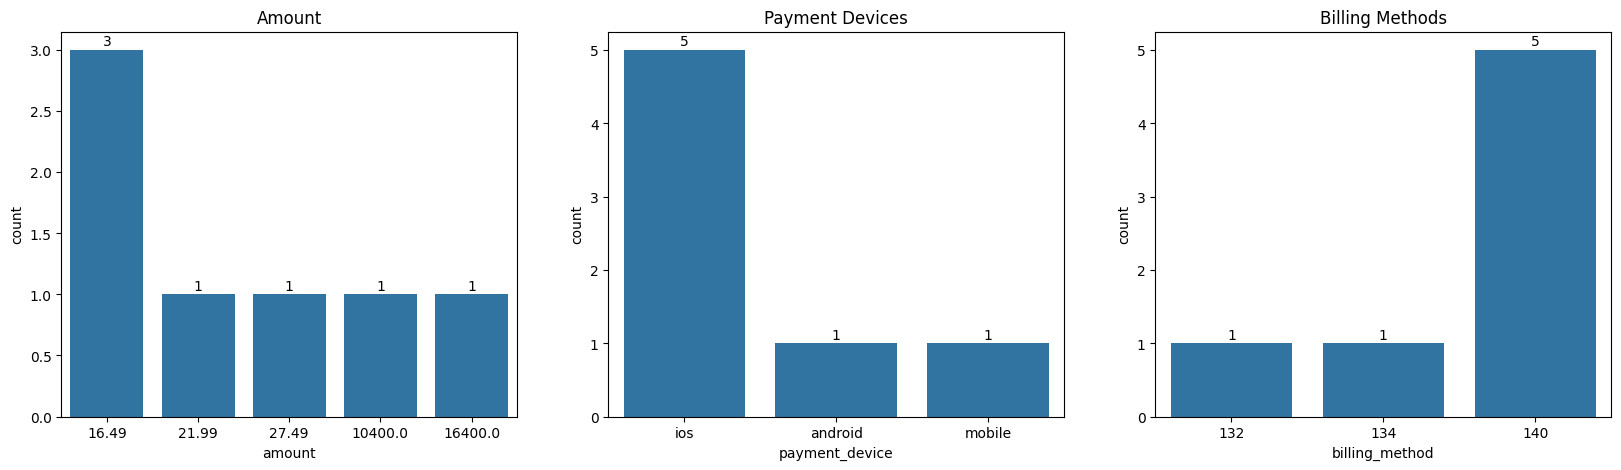

In [ ]:
# 그래프를 많이 그려봅시다
plt.style.use("default")

fig, axes = plt.subplots(
	nrows = 1, # 1행
	ncols = 3, # 2열
	figsize = (20, 5)
)

sns.countplot(
	data=df_conc3,
	x="amount",
	ax=axes[0]
)
axes[0].set_title("Amount")
axes[0].bar_label(axes[0].containers[0], padding = 1)

sns.countplot(
	data=df_conc3,
	x="payment_device",
	ax=axes[1]
)
axes[1].set_title("Payment Devices")
axes[1].bar_label(axes[1].containers[0], padding = 1)

sns.countplot(
	data=df_conc3,
	x="billing_method",
	ax=axes[2]
)
axes[2].set_title("Billing Methods")
axes[2].bar_label(axes[2].containers[0], padding = 1)

>Concurrent_Streams가 결측치인 데이터들

In [3]:
condition_isna = membership["concurrent_streams"].isna() #conc가 na인 조건
df_concNa = membership[condition_isna] #조건에 맞는 데이터프레임만을

>Concurrent_Streams가 결측치인 데이터들은 어떤 특성을 띄는가?

[Text(0, 1, '1'), Text(0, 1, '1'), Text(0, 1, '9'), Text(0, 1, '59')]

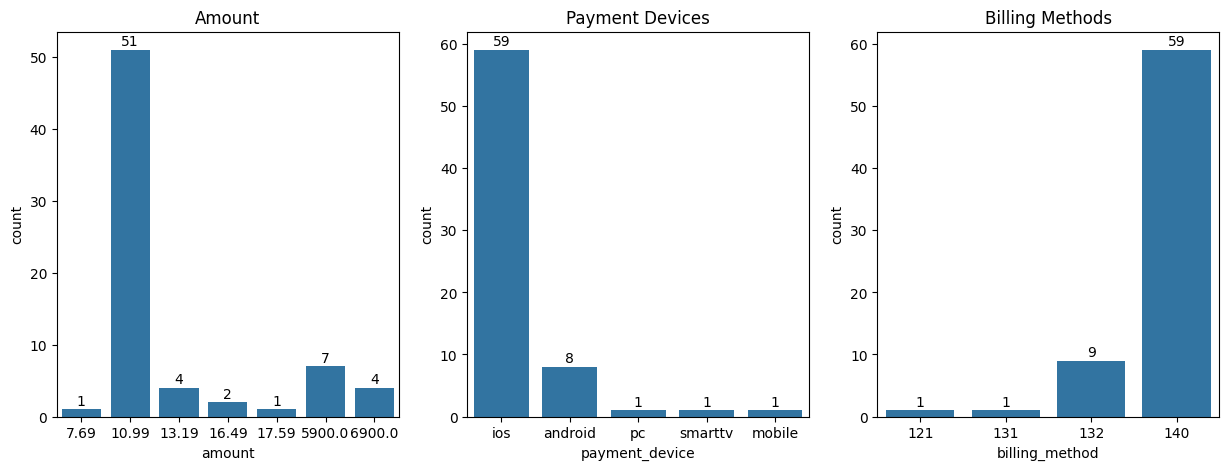

In [49]:
fig, axes = plt.subplots(
	nrows=1,
	ncols=3,
	figsize=(15, 5)
)

sns.countplot(
	data=df_concNa,
	x="amount",
	ax=axes[0]
)
axes[0].set_title("Amount")
axes[0].bar_label(axes[0].containers[0], padding=1)

sns.countplot(
	data=df_concNa,
	x="payment_device",
	ax=axes[1]
)
axes[1].set_title("Payment Devices")
axes[1].bar_label(axes[1].containers[0], padding = 1)

sns.countplot(
	data=df_concNa,
	x="billing_method",
	ax=axes[2]
)
axes[2].set_title("Billing Methods")
axes[2].bar_label(axes[2].containers[0], padding=1)

> 왜 Amount가 소숫점으로 나오는가? (달러)

In [63]:
billing140_condition = membership["billing_method"] == 140
df_billing140 = membership[billing140_condition]

Text(0.98, 0.95, 'N = 3094')

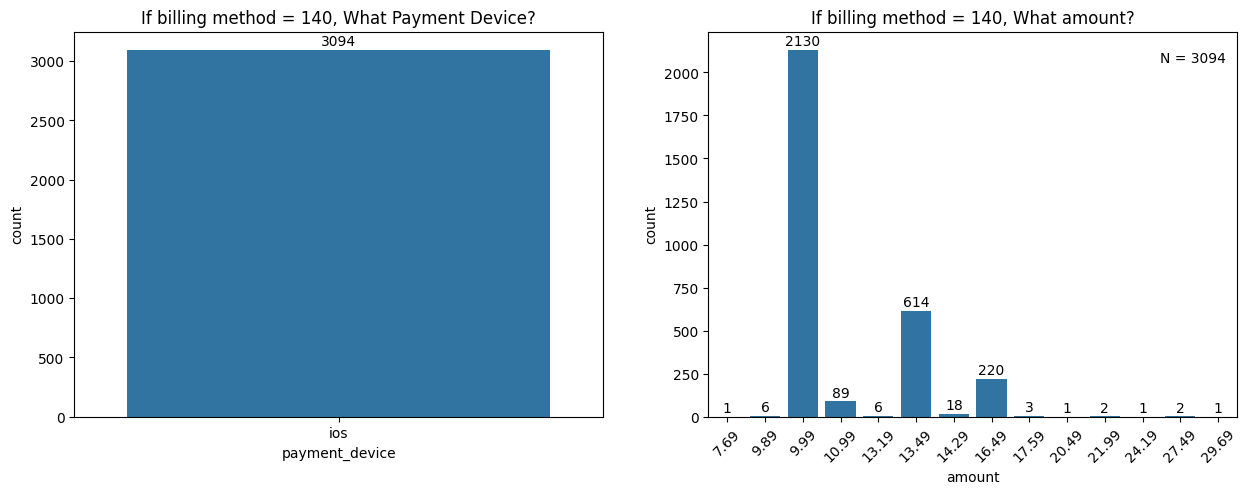

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
n_payment_device = df_billing140["payment_device"].notna().sum()

sns.countplot(
	data=df_billing140,
	x="payment_device",
	ax=axes[0]
)
axes[0].set_title("If billing method = 140, What Payment Device?")
axes[0].bar_label(axes[0].containers[0],padding=1)


sns.countplot(
	data=df_billing140,
	x="amount",
	ax=axes[1]
)
axes[1].set_title("If billing method = 140, What amount?")
axes[1].bar_label(axes[1].containers[0],padding=1)
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].text(
    0.98, 0.95,
    f"N = {n_payment_device}",
    transform=axes[1].transAxes,
    ha="right",
    va="top"
)

> 결론  

`Billing Method`가 140이면  
1. `Payment Device`가 ios이고 (100% 일치),  
2. `Amount`가 소숫점으로 떨어진다.

> 왜 이런 것일까?  

바로 애플의 정책 때문  
  
1. 애플 앱스토어가 USD 기반의 글로벌 가격 티어 체계를 사용.  
이로 인해 OTT서비스가 제공하는 요금제 별 금액을 달러로 데이터에 기록함.  

2. 동시에, 결제는 반드시 iOS 기기를 통해서만 처리(앱스토어 인앱결제는 Apple 생태계 전용 결제)  


> 연령에서, 미인증된 40대는 왜이리도 많은가?

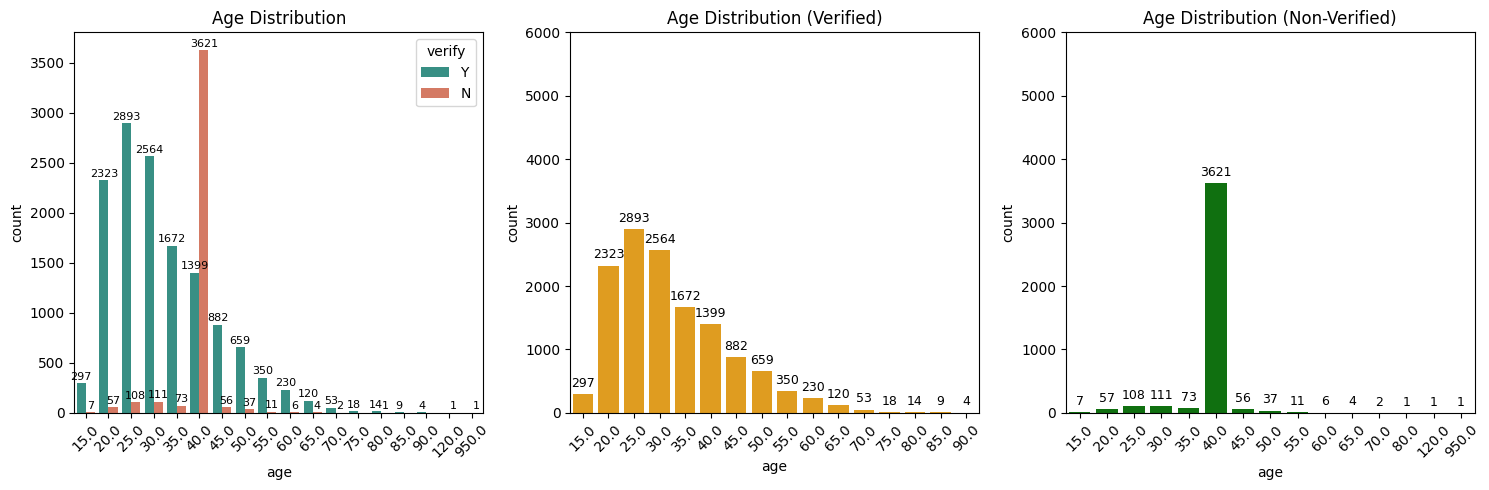

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age Distribution (Entire)
sns.countplot(
    data=membership[membership["is_user_verified"].isin(["Y", "N"])],
    x="age",
    hue="is_user_verified",
    hue_order=["Y", "N"],
    palette={"Y": "#2A9D8F", "N": "#E76F51"},
    ax=axes[0]
)
axes[0].set_title("Age Distribution")
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].legend(title="verify")
for container in axes[0].containers:
    axes[0].bar_label(container, padding=1, fontsize=8)

# Age Distribution (Verified)
sns.countplot(data=membership[membership["is_user_verified"] == "Y"], x="age", ax=axes[1], color="orange")
axes[1].set_title("Age Distribution (Verified)")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
axes[1].set_ylim(0, 6000)
plt.tight_layout()

# Age Distribution (Non-Verified)
sns.countplot(data=membership[membership["is_user_verified"] == "N"], x="age", ax=axes[2], color="green")
axes[2].set_title("Age Distribution (Non-Verified)")
axes[2].tick_params(axis="x", labelrotation=45)
axes[2].bar_label(axes[2].containers[0], padding=3, fontsize=9)
axes[2].set_ylim(0, 6000)
plt.tight_layout()

> `미 인증된`, `40대`가 너무 많은데? 더 파봐야겠다.

[Text(0, 1, '877'), Text(0, 1, '461'), Text(0, 1, '2758')]

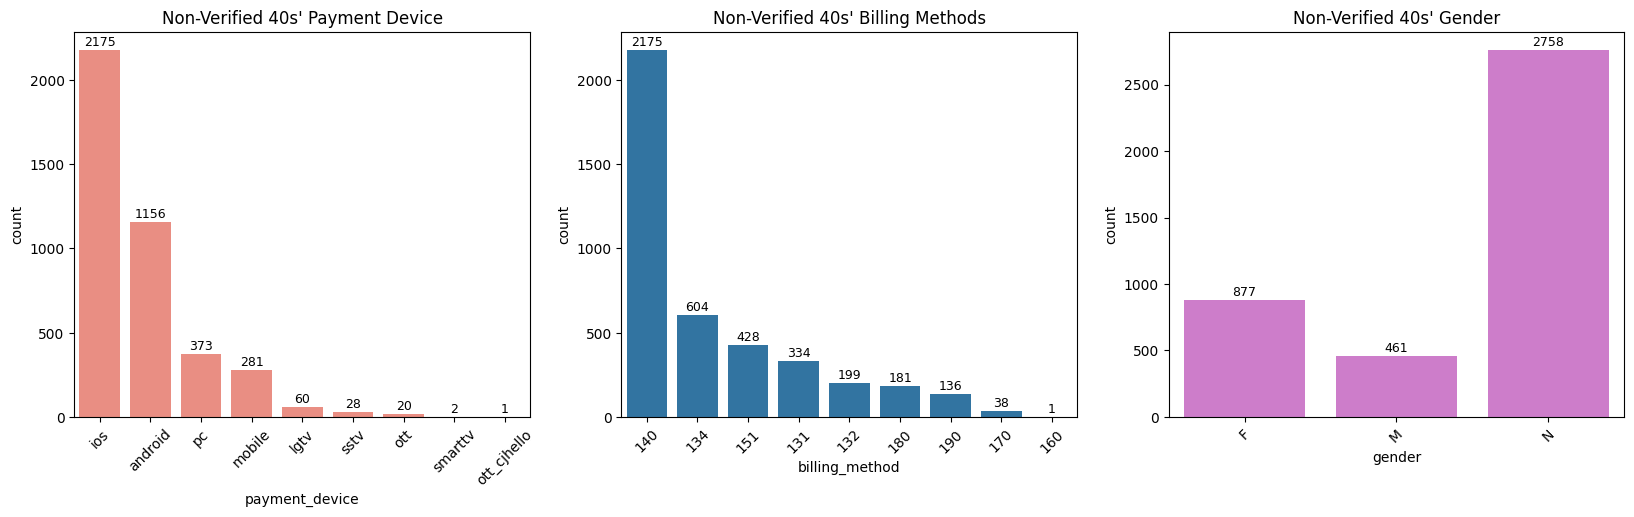

In [199]:
non_verified_40 = membership[membership["is_user_verified"] == "N"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(data=non_verified_40, x="payment_device", order=non_verified_40["payment_device"].value_counts().sort_values(ascending=False).index, ax=axes[0], color="salmon")
axes[0].set_title("Non-Verified 40s' Payment Device")
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].bar_label(axes[0].containers[0], padding=1, fontsize=9)

sns.countplot(
    data=non_verified_40, 
    x="billing_method", 
    order=non_verified_40["billing_method"].value_counts().sort_values(ascending=False).index, 
    ax=axes[1]
)
axes[1].set_title("Non-Verified 40s' Billing Methods")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].bar_label(axes[1].containers[0], padding=1, fontsize=9)

sns.countplot(
    data=non_verified_40,
    x="gender",
    order=sorted(non_verified_40["gender"].dropna().unique()),
    ax=axes[2], 
    color="orchid"
)
axes[2].set_title("Non-Verified 40s' Gender")
axes[2].tick_params(axis="x", labelrotation=45)
axes[2].bar_label(axes[2].containers[0], padding=1, fontsize=9)

> EDA 결과  

1. 미인증 40대들 중 ios 결제수단이면서 성별이 중립인 경우가 대다수를 차지하고 있었다.
2. payment_device가 ios면 billing_method는 140이라는 코드를 가진다.

# 도대체 왜?????????????

> 가설 1. iOS 결제방식 때문에 40대 미인증의 데이터가 폭증한 것이라면?  
  
주장 1. iOS 결제방식은 (사용자 → AppStore → OTT) 라는 골격으로 이루어진다.  
이 과정에서 애플은 IAP(In-App Purchase)를 통한 정보를 OTT 측에 제공하지 않음.  
대신, 애플은 OTT 서버에 `구독 이벤트 알림`을 보냄 (거래ID, 구독 상품 코드, 만료일, 갱신 여부 등)  

주장 2: 이 과정에서 사용자의 생년월일, 성별과 같은 인구통계 정보는 전달되지 않음.  
따라서 OTT 시스템은 iOS에서 인앱 결제로 구독하는 사용자에 대한 나이와 성별을 알 수 없음.
  
주장 3: 그 과정에서 알 수 없는 사용자는 기본값을 부여할 것으로 추정.  
그 기본값이 `age = 40`, `gender = N` 이 아닐까? 라는 가설.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19616\1475043925.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


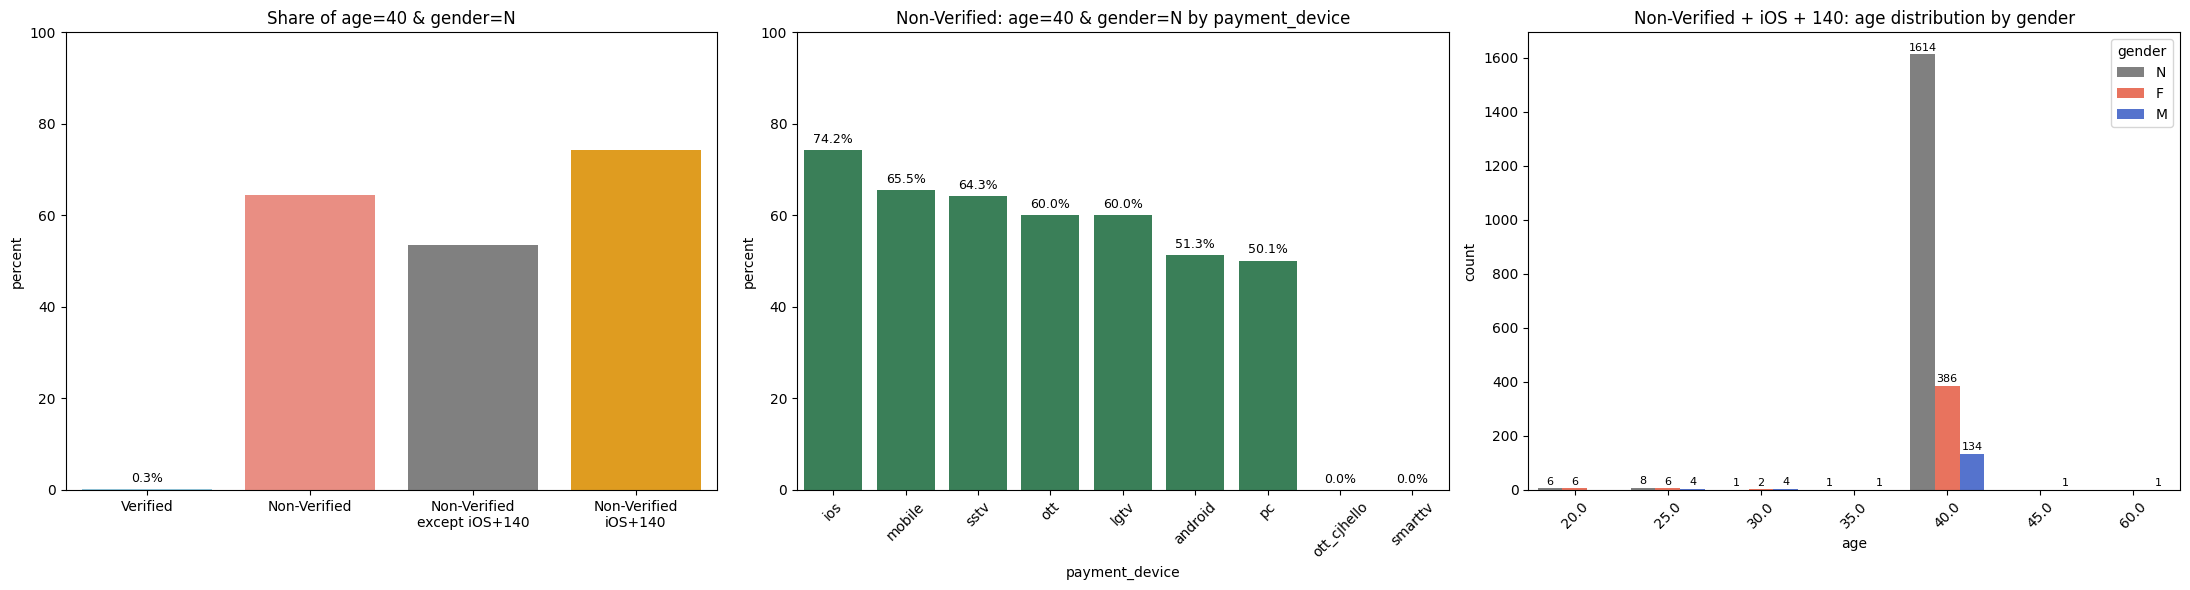

In [210]:
verified = membership[membership["is_user_verified"] == "Y"]
non_verified = membership[membership["is_user_verified"] == "N"]
non_verified_ios_140 = membership[
    (membership["is_user_verified"] == "N") &
    (membership["payment_device"] == "ios") &
    (membership["billing_method"] == 140)
]
non_verified_except_ios_140 = membership[
    (membership["is_user_verified"] == "N") &
    ~(
        (membership["payment_device"] == "ios") &
        (membership["billing_method"] == 140)
    )
]

plot_df_1 = pd.DataFrame({
    "group": [
        "Verified",
        "Non-Verified",
        "Non-Verified\nexcept iOS+140",
        "Non-Verified\niOS+140"
    ],
    "percent": [
        ((verified["age"] == 40) & (verified["gender"] == "N")).mean() * 100,
        ((non_verified["age"] == 40) & (non_verified["gender"] == "N")).mean() * 100,
        ((non_verified_except_ios_140["age"] == 40) & (non_verified_except_ios_140["gender"] == "N")).mean() * 100,
        ((non_verified_ios_140["age"] == 40) & (non_verified_ios_140["gender"] == "N")).mean() * 100
    ]
})

device_ratio = (
    non_verified
    .groupby("payment_device")
    .apply(lambda x: ((x["age"] == 40) & (x["gender"] == "N")).mean() * 100)
    .reset_index(name="percent")
    .sort_values("percent", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    data=plot_df_1,
    x="group",
    y="percent",
    ax=axes[0],
    palette=["skyblue", "salmon", "gray", "orange"]
)
axes[0].set_title("Share of age=40 & gender=N")
axes[0].set_ylabel("percent")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 100)
axes[0].bar_label(axes[0].containers[0], fmt="%.1f%%", padding=3, fontsize=9)

sns.barplot(
    data=device_ratio,
    x="payment_device",
    y="percent",
    ax=axes[1],
    color="seagreen"
)
axes[1].set_title("Non-Verified: age=40 & gender=N by payment_device")
axes[1].set_ylabel("percent")
axes[1].set_xlabel("payment_device")
axes[1].tick_params(axis="x", labelrotation=45)
axes[1].set_ylim(0, 100)
axes[1].bar_label(axes[1].containers[0], fmt="%.1f%%", padding=3, fontsize=9)

sns.countplot(
    data=non_verified_ios_140,
    x="age",
    hue="gender",
    order=sorted(non_verified_ios_140["age"].dropna().unique()),
    ax=axes[2],
    palette={"F": "tomato", "M": "royalblue", "N": "gray"}
)
axes[2].set_title("Non-Verified + iOS + 140: age distribution by gender")
axes[2].set_xlabel("age")
axes[2].tick_params(axis="x", labelrotation=45)
axes[2].legend(title="gender")

for container in axes[2].containers:
    axes[2].bar_label(container, padding=1, fontsize=8)

plt.tight_layout()
plt.show()

# EDA 최종 설명

> 첫 번째 그래프

단순히 "미인증 사용자에게 40세가 많은가?" 가 아님.  
iOS + billing_method 140 + 미인증이라는 조건이 붙는 순간 age=40, gender=N이라는 조합이 비정상적으로 많이 나타나는가? 

첫 번째 그래프처럼 집단을 4개로 나누어 보아 어느 조합에서 과도하게 나타나는지를 확인하고자 했음.  

> 두 번째 그래프

첫 번째 그래프에서 non-Verified인 유저들 중 iOS 결제인 사람이 유독 많음을 알 수 있었음.
그러면 그 튐이 iOS에서 상대적으로 강한가? 

만약 만약 ios만 유독 높고, android, pc, mobile은 상대적으로 훨씬 낮다면  
이 경우는 "애플 결제 구조 때문에 OTT가 인구통계 정보를 못 받아서 기본값 처리했을 가능성"이 더 높은 것.  

반대로 android, pc, mobile도 전부 높고, ios만 조금 더 높은 수준이라면  
이 경우는 "iOS가 유독 심하긴 하지만, 근본 문제는 미인증 사용자 전체의 정보 수집 또는 적재 로직일 가능성"이 큰 것임.  

> 세 번째 그래프

Non-Verified + iOS + 140 집단만 따로 떼어 놓고, 그 안에서 age 분포를 그리고, 가능하면 hue="gender"를 써서 성별까지 함께 나눠 봄.  
정말 age=40에 비정상적으로 몰렸는가? 그 안에서도 gender=N이 압도적으로 높은건가?  

# 결론

iOS 인앱결제 집단에서 40 / N 기본값 의심 현상이 매우 강하게 보인다.  
그러나 근본적으로는 미인증 사용자 전반에 인구통계 기본값 대체 로직이 들어가 있을 가능성이 더 크다.  

1. billing_method = 140과 payment_device = ios는 이 데이터에서 사실상 같은 집합. 즉 iOS과 140은 같이 보아도 됌.

2. 인증 사용자 Y에서는 age = 40 & gender = N 비율이 거의 없음.(대략 0.27% 수준. 결국 MCAR인 셈)

3. 미인증 사용자 N에서는 age = 40 & gender = N 비율이 매우 높음. (64.55%)

4. 미인증이면서 ios = 140 집단에서는 그 비율이 더 높음 (74.21%)

5. 하지만 iOS를 제외한 미인증 집단에서도 age = 40 & gender = N 비율이 높음 (대략 53.62%)

6. 따라서 40 / N 현상은 iOS 집단에서 가장 강하게 보이지만, iOS만의 현상은 아닌 것으로 판명됌.